# Phase 5: analytical datasets

Run all cells after notebook 03 (or `python -m src.cleaning.pipeline`). This notebook uses reusable source functions and stops before phase 6, PostgreSQL.

| Output | One row represents | Primary key |
| --- | --- | --- |
| orders | One order, including canceled/unavailable orders | order_id |
| customers | One person-level customer identity | customer_unique_id |
| products | One catalog product, including unsold products | product_id |

Inspect the source grains first. Items and payments are separate one-to-many children of orders; joining them directly would multiply amounts.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir() and (p / 'plan.md').is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.transformation.transformations import (
    load_processed_tables, build_analytical_datasets, save_analytical_datasets,
)
from src.transformation.validation import validate_analytical_datasets
from src.utils.parquet import verify_parquet

processed_dir = root / 'data' / 'processed'
tables = load_processed_tables(processed_dir)
for name, df in tables.items():
    print(f'{name:40s} {df.shape}')

olist_orders_dataset                     (99441, 11)
olist_order_items_dataset                (112650, 7)
olist_order_payments_dataset             (103886, 7)
olist_order_reviews_dataset              (98673, 8)
olist_customers_dataset                  (99441, 5)
olist_products_dataset                   (32951, 10)
product_category_name_translation        (74, 2)


In [2]:
pd.set_option("display.max_columns", None)

def look(name, n=5):
    df = tables[name]
    print(name, df.shape, "\n")
    df.info()
    display(df.head(n))

In [3]:
look("olist_orders_dataset")

olist_orders_dataset (99441, 11) 

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   flag_carrier_before_approval   99441 non-null  bool          
 9   flag_delivery_before_carrier   99441 non-null  bool          
 10  flag_delivered_missing_date    99441 non-null  bool       

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_carrier_before_approval,flag_delivery_before_carrier,flag_delivered_missing_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False


In [4]:
df = tables["olist_order_items_dataset"]
print(df["order_id"].is_unique)        # one row per order?
print(df["order_id"].value_counts().describe())   # how many rows per order

False
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: count, dtype: float64


## Join contracts and construction

Orders join customers many-to-one on `customer_id`. Items join product categories many-to-one and aggregate to orders; payments aggregate independently. The cleaned review table must already have one row per order. All three child summaries join orders one-to-one. Invalid keys or orphan references fail with an actionable error rather than silently dropping rows.

Customer features group orders by `customer_unique_id`. Product sales aggregate item rows independently of reviews; product reviews use distinct product/order pairs so multiple units cannot weight a rating.

In [5]:
source_grains = {
    'olist_orders_dataset': ['order_id'],
    'olist_customers_dataset': ['customer_id'],
    'olist_order_items_dataset': ['order_id', 'order_item_id'],
    'olist_order_payments_dataset': ['order_id', 'payment_sequential'],
    'olist_order_reviews_dataset': ['order_id'],
    'olist_products_dataset': ['product_id'],
    'product_category_name_translation': ['product_category_name'],
}
display(pd.DataFrame([
    {'table': name, 'rows': len(tables[name]), 'key': ', '.join(key),
     'duplicate_keys': int(tables[name].duplicated(key).sum()),
     'null_key_rows': int(tables[name][key].isna().any(axis=1).sum())}
    for name, key in source_grains.items()
]))
analytical = build_analytical_datasets(tables)
orders = analytical['orders']
customers = analytical['customers']
products = analytical['products']
display(pd.DataFrame([
    {'dataset': name, 'rows': len(frame), 'columns': len(frame.columns)}
    for name, frame in analytical.items()
]))

,table,rows,key,duplicate_keys,null_key_rows
0,olist_orders_dataset,99441,order_id,0,0
1,olist_customers_dataset,99441,customer_id,0,0
2,olist_order_items_dataset,112650,"order_id, order_item_id",0,0
3,olist_order_payments_dataset,103886,"order_id, payment_sequential",0,0
4,olist_order_reviews_dataset,98673,order_id,0,0
5,olist_products_dataset,32951,product_id,0,0
6,product_category_name_translation,74,product_category_name,0,0


,dataset,rows,columns
0,orders,99441,45
1,customers,96096,14
2,products,32951,24


## Reconciliation

Every source key must remain visible, each target key must be unique, and counts and observed monetary totals must agree. Money uses an absolute tolerance of one cent with no relative tolerance. Payments and item value plus freight are reconciled to their respective sources; they are not assumed to equal each other.

In [6]:
reconciliation = validate_analytical_datasets(tables, analytical)
display(reconciliation)
assert reconciliation['passed'].all()
for name, frame in analytical.items():
    print(name)
    display(frame.head(3))

,check,actual,expected,passed
0,orders: row count,99441,99441,True
1,orders: full key population,True,True,True
2,customers: row count,96096,96096,True
3,customers: full key population,True,True,True
4,products: row count,32951,32951,True
5,products: full key population,True,True,True
6,orders: item value,13591643.7,13591643.7,True
7,orders: freight,2251909.54,2251909.54,True
8,orders: payments,16008872.12,16008872.12,True
9,customers: spend,16008872.12,16008872.12,True


orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,flag_carrier_before_approval,flag_delivery_before_carrier,flag_delivered_missing_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_item_value,total_freight,item_count,average_item_price,product_count,seller_count,category_count,missing_item_price_count,missing_freight_count,total_payment,payment_count,missing_payment_value_count,flag_zero_installments,flag_missing_first_payment,review_score,has_comment,has_items,has_payments,has_review,approval_delay_days,shipping_delay_days,delivery_duration_days,carrier_delivery_days,delivery_delay_days,is_late,purchase_year,purchase_month,purchase_day_of_week,purchase_hour,payment_item_difference
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,29.99,8.72,1,29.99,1,1,1,0,0,38.71,3,0,False,False,4.0,True,True,True,True,0.007431,2.366493,8.436574,6.062650,-8.0,False,2017,2017-10,0,10,1.776357e-15
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1,118.70,1,1,1,0,0,141.46,1,0,False,False,4.0,True,True,True,True,1.279745,0.462882,13.782037,12.039410,-6.0,False,2018,2018-07,1,20,3.552714e-15
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1,159.90,1,1,1,0,0,179.12,1,0,False,False,5.0,False,True,True,True,0.011505,0.204595,9.394213,9.178113,-18.0,False,2018,2018-08,2,8,0.000000e+00


customers


,customer_unique_id,order_count,total_spend,average_order_value,total_items_purchased,first_purchase,last_purchase,average_delivery_duration_days,average_review_score,reviewed_order_count,orders_with_payment,orders_with_known_payment,active_period_days,is_repeat_customer
0,861eff4711a542e4b93843c6dd7febb0,1,146.87,146.87,1,2017-05-16 15:05:35,2017-05-16 15:05:35,8.812500,4.0,1,1,1,0.0,False
1,290c77bc529b7ac935b93aa66c333dc3,1,335.48,335.48,1,2018-01-12 20:48:24,2018-01-12 20:48:24,16.661748,5.0,1,1,1,0.0,False
2,060e732b5b29e8181a18229c7b0b2b5e,1,157.73,157.73,1,2018-05-19 16:07:45,2018-05-19 16:07:45,26.077153,5.0,1,1,1,0.0,False


products


,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,flag_zero_weight,product_category_name_english,flag_missing_category_translation,units_sold,order_count,customer_count,revenue,total_freight,average_selling_price,average_freight,seller_count,missing_price_count,missing_freight_count,average_review_score,review_count
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,False,perfumery,False,1,1,1,10.91,7.39,10.91,7.39,1,0,0,5.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,False,art,False,1,1,1,248.00,17.99,248.00,17.99,1,0,0,5.0,1
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,False,sports_leisure,False,1,1,1,79.80,7.82,79.80,7.82,1,0,0,5.0,1


## Join-created nulls and coverage

Missing child rows have zero counts and unknown monetary values. A missing review is not a zero rating. Payment flags and comment indicators remain nullable when no child exists. Unsold products and customers with no orders remain in the outputs; their observed sales/spend are zero and their averages remain null.

A missing category translation is flagged and the product retained. Source-null amounts are counted separately; sums contain observed values and remain null for entirely unknown groups.

In [7]:
coverage = pd.Series({
    'orders_without_items': int((~orders['has_items']).sum()),
    'orders_without_payments': int((~orders['has_payments']).sum()),
    'orders_without_reviews': int((~orders['has_review']).sum()),
    'customers_without_orders': int((customers['order_count'] == 0).sum()),
    'products_without_sales': int((products['units_sold'] == 0).sum()),
    'products_without_translation': int(products['flag_missing_category_translation'].sum()),
}, name='rows')
display(coverage.to_frame())
for name, frame in analytical.items():
    nulls = frame.isna().sum()
    print(name)
    display(nulls[nulls > 0].rename('null_count').to_frame())

,rows
orders_without_items,775
orders_without_payments,1
orders_without_reviews,768
customers_without_orders,0
products_without_sales,0
products_without_translation,0


orders


,null_count
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
total_item_value,775
total_freight,775
average_item_price,775
total_payment,1
flag_zero_installments,1
flag_missing_first_payment,1
review_score,768


customers


,null_count
total_spend,1
average_order_value,1
average_delivery_duration_days,2740
average_review_score,716


products


,null_count
product_name_length,610
product_description_length,610
product_photos_qty,610
product_weight_g,6
product_length_cm,2
product_height_cm,2
product_width_cm,2
average_review_score,162


## Feature distributions and suspicious values

Duration features are elapsed fractional days. Negative intervals remain visible with existing cleaning flags; no timestamps are corrected here. Delivery against estimate compares calendar dates, so delivery at 18:00 on the expected date is on time. An unknown delivery date produces an unknown late indicator.

These retrospective features include all statuses. Item revenue is gross recorded item value, not net realized revenue; customer spend is recorded payments. Product review scores describe orders and cannot isolate product satisfaction.

In [8]:
duration_columns = [
    'approval_delay_days', 'shipping_delay_days', 'delivery_duration_days',
    'carrier_delivery_days', 'delivery_delay_days',
]
display(orders[duration_columns + ['total_item_value', 'total_payment', 'item_count']].describe().T)
display(orders[duration_columns].lt(0).sum().rename('negative_intervals').to_frame())
display(orders.groupby('order_status', dropna=False).agg(
    orders=('order_id', 'size'), delivered_dates=('delivery_duration_days', 'count'),
    reviewed_orders=('review_score', 'count'),
))
display(orders.loc[orders['payment_item_difference'].abs() > 0.01,
    ['order_id', 'order_status', 'total_item_value', 'total_freight', 'total_payment', 'payment_item_difference']].head(10))

affected = orders[orders['shipping_delay_days'].lt(0) | orders['carrier_delivery_days'].lt(0)]
display(affected[['order_id', 'order_status', *duration_columns]].head(10))

,count,mean,std,min,25%,50%,75%,max
approval_delay_days,99281.0,0.434129,1.084917,0.000000,0.008958,0.014306,0.607535,187.882523
shipping_delay_days,97644.0,2.805038,3.549427,-171.219005,0.875509,1.818397,3.580469,125.762569
delivery_duration_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
carrier_delivery_days,96475.0,9.330547,8.760122,-16.096169,4.099948,7.099769,12.029115,205.190972
delivery_delay_days,96476.0,-11.876881,10.183854,-147.000000,-17.000000,-12.000000,-7.000000,188.000000
total_item_value,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000
total_payment,99440.0,160.990267,221.951257,0.000000,62.010000,105.290000,176.970000,13664.080000
item_count,99441.0,1.132833,0.545666,0.000000,1.000000,1.000000,1.000000,21.000000


,negative_intervals
approval_delay_days,0
shipping_delay_days,1359
delivery_duration_days,0
carrier_delivery_days,23
delivery_delay_days,88649


,orders,delivered_dates,reviewed_orders
order_status,,,
approved,2,0,2
canceled,625,6,605
created,5,0,3
delivered,96478,96470,95832
invoiced,314,0,309
processing,301,0,295
shipped,1107,0,1032
unavailable,609,0,595


,order_id,order_status,total_item_value,total_freight,total_payment,payment_item_difference
464,8adafb3466daa5395694d3a906ff9d40,delivered,168.00,50.02,218.00,-0.02
867,bb2e64c3040ceb9b7ca2bfc602adca08,delivered,248.00,9.36,257.34,-0.02
1080,84d6d9710c8af32b5e88f2d1c14ab871,delivered,49.90,7.78,61.70,4.02
1126,74016effecaa79d592487f6a4ee47d4b,delivered,36.99,14.52,56.96,5.45
1669,239f380355f65dcb68551f07d16fc4a8,delivered,149.00,73.63,251.63,29.00
1729,4c57f545143e8865ca2347d8cba154a7,delivered,124.99,14.62,151.01,11.40
1986,6e57e23ecac1ae881286657694444267,delivered,330.00,20.41,333.91,-16.50
2277,b38b3526b8b8fdc807e8a0a42ab78573,delivered,22.32,7.74,30.19,0.13
2357,051fcda88d997d3ff86012da2a556342,delivered,49.00,7.60,51.70,-4.90
2541,8b5058499c412c6cf8d013de40e4f9d2,delivered,29.45,19.32,51.02,2.25


,order_id,order_status,approval_delay_days,shipping_delay_days,delivery_duration_days,carrier_delivery_days,delivery_delay_days
15,dcb36b511fcac050b97cd5c05de84dc3,delivered,5.185995,-1.359051,13.855093,10.028148,-13.0
64,688052146432ef8253587b930b01a06d,delivered,2.400799,-0.962593,2.447049,1.008843,-21.0
199,58d4c4747ee059eeeb865b349b41f53a,delivered,5.446076,-2.440891,4.464433,1.459248,-6.0
210,412fccb2b44a99b36714bca3fef8ad7b,delivered,0.584583,-0.005475,1.872650,1.293542,-7.0
415,56a4ac10a4a8f2ba7693523bb439eede,delivered,5.434977,-3.394549,5.458935,3.418507,-9.0
481,32e4fa9bb468884309b58b9348de70c3,delivered,0.988715,-0.071597,2.911076,1.993958,-16.0
483,4df92d82d79c3b52c7138679fa9b07fc,delivered,5.499086,-3.364491,3.308171,1.173576,-10.0
585,16e38caa92e342c7780f68832f832d4d,delivered,0.655208,-0.071979,16.973715,16.390486,-14.0
615,b9afddbdcfadc9a87b41a83271c3e888,delivered,0.010012,-0.026539,8.047095,8.063623,-11.0
817,6051e6d3da9a50b7325cbe9c81025062,delivered,1.702199,-1.178773,1.966806,1.443380,-14.0


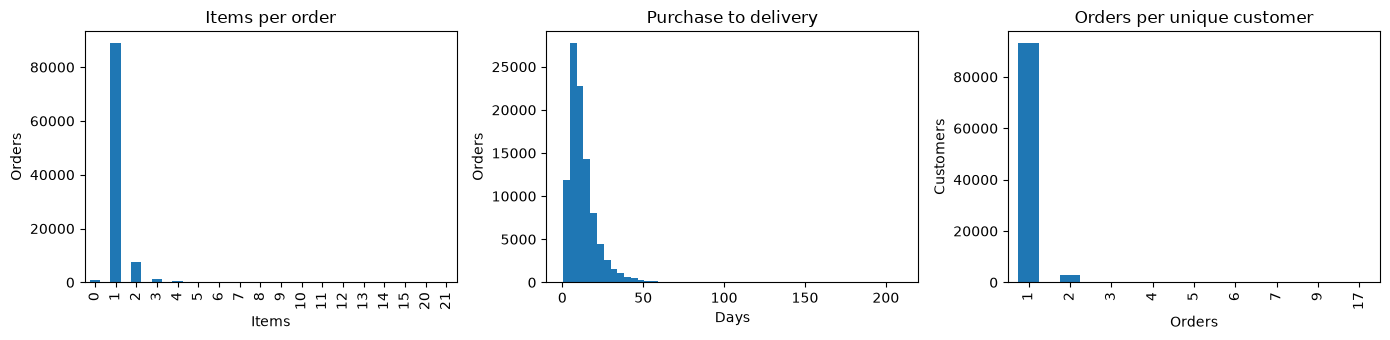

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
orders['item_count'].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set(title='Items per order', xlabel='Items', ylabel='Orders')
orders['delivery_duration_days'].dropna().plot.hist(bins=50, ax=axes[1])
axes[1].set(title='Purchase to delivery', xlabel='Days', ylabel='Orders')
customers['order_count'].value_counts().sort_index().plot.bar(ax=axes[2])
axes[2].set(title='Orders per unique customer', xlabel='Orders', ylabel='Customers')
fig.tight_layout()
plt.show()

## Validated exports

Write the three Parquet files and `reconciliation.csv` under `data/processed/analytical/`. Every export is read back and compared exactly for values, nulls, and dtypes before replacing an existing file. Database work begins in phase 6 and is outside this notebook.

In [10]:
output_dir = processed_dir / 'analytical'
save_analytical_datasets(tables, analytical, output_dir)
for name, frame in analytical.items():
    path = output_dir / f'{name}.parquet'
    verify_parquet(frame, path)
    print(f'{path.name}: {len(frame):,} rows; exact Parquet round trip passed')

orders.parquet: 99,441 rows; exact Parquet round trip passed
customers.parquet: 96,096 rows; exact Parquet round trip passed
products.parquet: 32,951 rows; exact Parquet round trip passed
